In [1]:
import cv2
import os
import numpy as np
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter


In [2]:
def load_data(train):
    data = []
    labels = []

    for label in os.listdir(train):
        label_path = os.path.join(train, label)

        if not os.path.isdir(label_path):
            continue

        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (128, 128))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8,8),
                cells_per_block=(2,2),
                block_norm='L2-Hys'
            )

            data.append(features)
            labels.append(label)

    return np.array(data), np.array(labels)


In [3]:

X_train, y_train = load_data("tests/train")
X_valid, y_valid = load_data("tests/valid")
X_test, y_test = load_data("tests/test")

print("Train size:", X_train.shape)
print("Valid size:", X_valid.shape)
print("Test size:", X_test.shape)

Train size: (3403, 8100)
Valid size: (1394, 8100)
Test size: (1333, 8100)


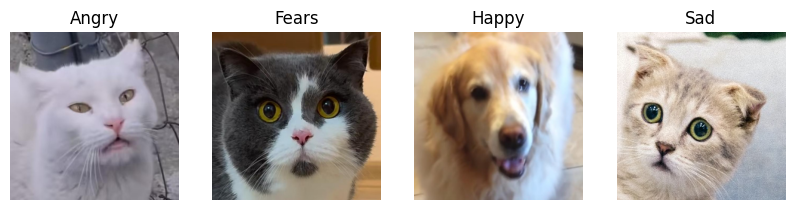

In [4]:

plt.figure(figsize=(10,5))
i = 1
labels_list = os.listdir("tests/train")

for label in labels_list:
    label_path = os.path.join("tests/train", label)

    if not os.path.isdir(label_path):
        continue

    img_name = os.listdir(label_path)[0]
    img_path = os.path.join(label_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(labels_list), i)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
    i += 1

plt.show()

In [5]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)


Validation Accuracy: 77.76

Test Accuracy: 92.2

Classification Report:
               precision    recall  f1-score   support

       Angry       0.92      0.91      0.91       350
       Fears       1.00      0.92      0.96       260
       Happy       0.92      0.91      0.91       377
         Sad       0.88      0.95      0.91       346

    accuracy                           0.92      1333
   macro avg       0.93      0.92      0.92      1333
weighted avg       0.92      0.92      0.92      1333


Confusion Matrix:
 [[318   0  18  14]
 [  8 240   3   9]
 [ 12   0 342  23]
 [  8   0   9 329]]


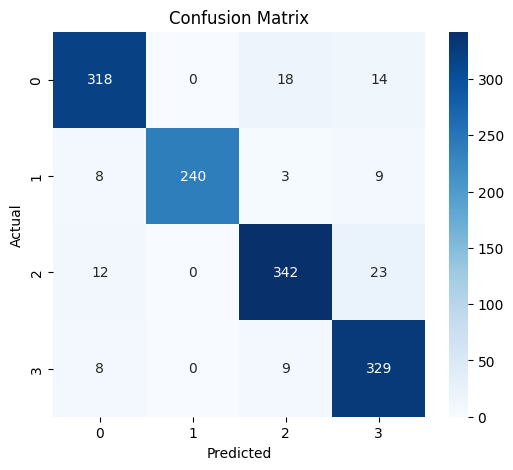

In [7]:
y_pred_valid = model.predict(X_valid)
y_pred_test = model.predict(X_test)
print("\nValidation Accuracy:", round(accuracy_score(y_valid, y_pred_valid)*100, 2))
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_test)*100, 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)


Validation Accuracy: 73.89

Test Accuracy: 90.77

Classification Report:
               precision    recall  f1-score   support

       Angry       0.87      0.91      0.89       350
       Fears       0.98      0.95      0.96       260
       Happy       0.93      0.85      0.88       377
         Sad       0.88      0.94      0.91       346

    accuracy                           0.91      1333
   macro avg       0.91      0.91      0.91      1333
weighted avg       0.91      0.91      0.91      1333


Confusion Matrix:
 [[320   3  14  13]
 [  3 247   3   7]
 [ 32   2 319  24]
 [ 13   1   8 324]]


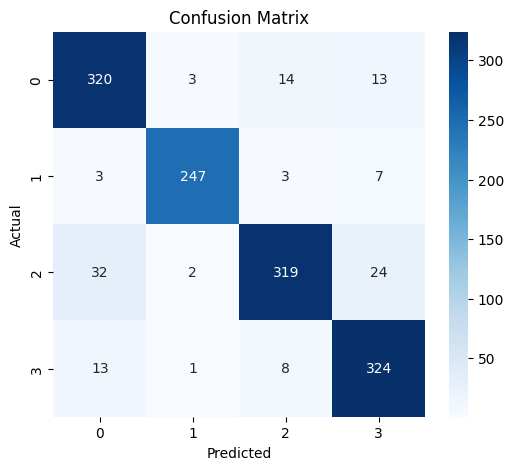

In [9]:
y_pred_valid = model.predict(X_valid)
y_pred_test = model.predict(X_test)
print("\nValidation Accuracy:", round(accuracy_score(y_valid, y_pred_valid)*100, 2))
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_test)*100, 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()


Validation Accuracy: 68.72

Test Accuracy: 89.05

Classification Report:
               precision    recall  f1-score   support

       Angry       0.86      0.91      0.88       350
       Fears       0.92      0.94      0.93       260
       Happy       0.94      0.81      0.87       377
         Sad       0.86      0.92      0.89       346

    accuracy                           0.89      1333
   macro avg       0.89      0.90      0.89      1333
weighted avg       0.89      0.89      0.89      1333


Confusion Matrix:
 [[319   6   8  17]
 [  4 244   4   8]
 [ 33  12 307  25]
 [ 17   3   9 317]]


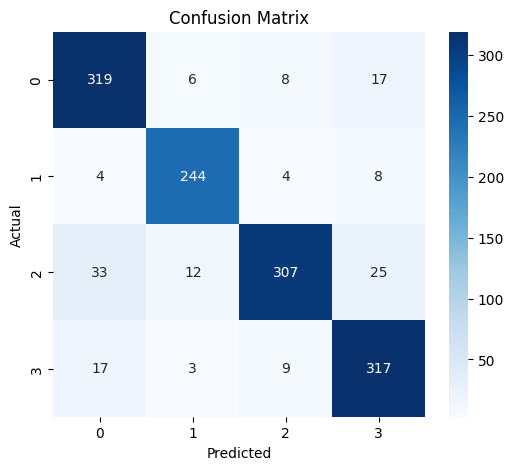

In [11]:
y_pred_valid = model.predict(X_valid)
y_pred_test = model.predict(X_test)
print("\nValidation Accuracy:", round(accuracy_score(y_valid, y_pred_valid)*100, 2))
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_test)*100, 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()


Validation Accuracy: 43.47

Test Accuracy: 49.59

Classification Report:
               precision    recall  f1-score   support

       Angry       0.53      0.49      0.51       350
       Fears       1.00      0.10      0.19       260
       Happy       0.41      0.91      0.57       377
         Sad       0.79      0.34      0.48       346

    accuracy                           0.50      1333
   macro avg       0.68      0.46      0.44      1333
weighted avg       0.66      0.50      0.46      1333


Confusion Matrix:
 [[172   0 169   9]
 [ 61  27 153  19]
 [ 30   0 343   4]
 [ 59   0 168 119]]


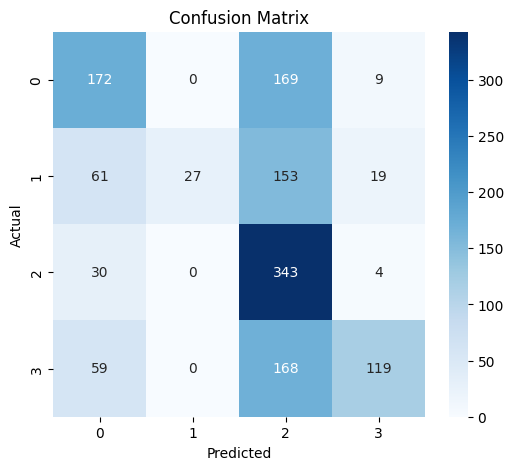

In [14]:
y_pred_valid = model.predict(X_valid)
y_pred_test = model.predict(X_test)
print("\nValidation Accuracy:", round(accuracy_score(y_valid, y_pred_valid)*100, 2))
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_test)*100, 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import joblib
print("\nModels Accuracy Comparison:")
models = {
    "k-Nearest-Neighbors": KNeighborsClassifier(),
    "Decision-Tree": DecisionTreeClassifier(),
    "Random-Forest": RandomForestClassifier(),
    "Logistic-Regression": LogisticRegression(max_iter=1000)
}

best_model = None
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    print(f"{name}: {round(acc * 100, 2)}%") 
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

joblib.dump(best_model, "furaffecta_model.pkl")

print("Best model saved with accuracy:", round(best_accuracy * 100, 2), "%")


Models Accuracy Comparison:
k-Nearest-Neighbors: 49.59%
Decision-Tree: 88.97%
Random-Forest: 91.97%
Logistic-Regression: 90.77%
Best model saved with accuracy: 91.97 %
